# Directional Grid Advection with Graph Attention

This notebook trains a **GraphKoopmanModel** with a **GATEncoder** on a 2D lattice
where node features propagate **directionally** — mostly from west and north
neighbors. That asymmetric coupling is a setting where attention can learn
*which* neighbors matter, while GCN layers tend to aggregate all neighbors
uniformly.

We use :class:`~koopman_graph.datasets.AnisotropicAdvectionGridBenchmark` and
compare GAT against a GCN encoder on the same rollout task.


## The encode → Koopman step → decode workflow

1. **Encode (GAT lifting):** Graph attention maps node features into latent space
   while learning neighbor importance.
2. **Koopman step:** A learned matrix $K$ advances latent states linearly.
3. **Decode:** A GCN decoder maps latent states back to physical features.

Training includes an autoregressive rollout term so multi-step `predict` matches
the optimization objective.


In [1]:
import warnings

from tqdm.std import TqdmWarning

warnings.filterwarnings("ignore", category=TqdmWarning)

import os

import matplotlib

if os.environ.get("PYTEST_CURRENT_TEST"):
    matplotlib.use("Agg")

import matplotlib.pyplot as plt

try:
    from IPython import get_ipython

    if get_ipython() is not None and not os.environ.get("PYTEST_CURRENT_TEST"):
        get_ipython().run_line_magic("matplotlib", "inline")
except (ImportError, NameError):
    pass

import torch

from koopman_graph import GATEncoder, GNNDecoder, GNNEncoder, GraphKoopmanModel
from koopman_graph.datasets import AnisotropicAdvectionGridBenchmark
from koopman_graph.datasets.grid import grid_node_index
from koopman_graph.training import constant_loss_weights


## Generate advection grid data

`AnisotropicAdvectionGridBenchmark` builds an $8 \times 8$ lattice where each
node mixes **70%** of its update from the west neighbor, **20%** from the north
neighbor, and the remainder from other available neighbors. Features flow
diagonally across the grid like a prevailing wind from the northwest.


In [2]:
NUM_ROWS = 8
NUM_COLS = 8

data_sequence = AnisotropicAdvectionGridBenchmark.generate(
    num_rows=NUM_ROWS,
    num_cols=NUM_COLS,
    num_timesteps=40,
    in_channels=3,
    seed=42,
    decay_rate=0.85,
    west_weight=0.7,
    north_weight=0.2,
    noise_std=0.005,
)

print(f"Snapshots: {data_sequence.num_timesteps}")
print(f"Nodes: {data_sequence.num_nodes}")
print(f"Edges: {data_sequence.edge_index.shape[1]}")
print(f"Feature dim: {data_sequence.in_channels}")


Snapshots: 40
Nodes: 64
Edges: 224
Feature dim: 3


Plot trajectories at a corner, edge, and interior node.


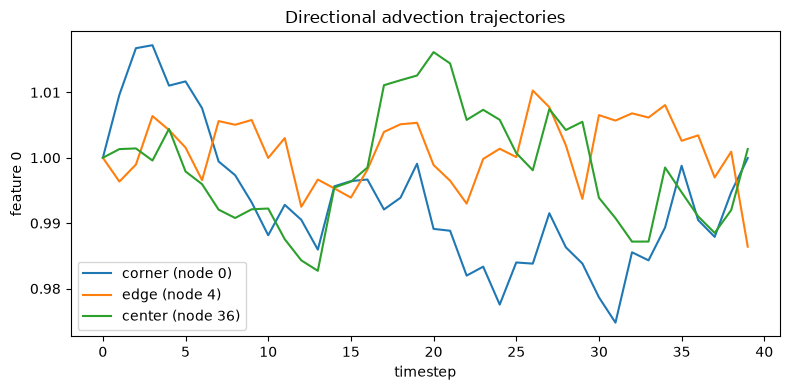

In [3]:
feature_idx = 0
node_ids = [
    grid_node_index(0, 0, num_cols=NUM_COLS),
    grid_node_index(0, NUM_COLS // 2, num_cols=NUM_COLS),
    grid_node_index(NUM_ROWS // 2, NUM_COLS // 2, num_cols=NUM_COLS),
]
node_labels = ["corner", "edge", "center"]
times = torch.arange(data_sequence.num_timesteps)

fig, ax = plt.subplots(figsize=(8, 4))
for node_id, label in zip(node_ids, node_labels, strict=True):
    values = torch.stack([snap.x[node_id, feature_idx] for snap in data_sequence])
    ax.plot(times, values.numpy(), label=f"{label} (node {node_id})")
ax.set_xlabel("timestep")
ax.set_ylabel(f"feature {feature_idx}")
ax.set_title("Directional advection trajectories")
ax.legend()
fig.tight_layout()
plt.show()


## Build the GAT model

`GATEncoder` uses multi-head attention (`heads=4`) to lift node features. The
decoder remains a GCN, following the hybrid encoder/decoder design used
throughout KoopmanGraph.


In [4]:
in_channels = data_sequence.in_channels
hidden_channels = 64
latent_dim = 64
out_channels = in_channels

gat_encoder = GATEncoder(
    in_channels,
    hidden_channels,
    latent_dim,
    heads=4,
    dropout=0.0,
)
decoder = GNNDecoder(latent_dim, hidden_channels, out_channels)
gat_model = GraphKoopmanModel(
    encoder=gat_encoder,
    decoder=decoder,
    latent_dim=latent_dim,
    time_step=0.1,
)

print(gat_model)


GraphKoopmanModel(
  (encoder): GATEncoder(
    (activation): ReLU()
    (convs): ModuleList(
      (0): GATConv(3, 64, heads=4)
      (1): GATConv(64, 64, heads=4)
    )
  )
  (decoder): GNNDecoder(
    (activation): ReLU()
    (convs): ModuleList(
      (0): GCNConv(64, 64)
      (1): GCNConv(64, 3)
    )
  )
  (koopman): KoopmanOperator()
)


## Train the GAT model


In [5]:
predict_steps = 10
EPOCHS = 40 if os.environ.get("PYTEST_CURRENT_TEST") else 120
loss_weights = constant_loss_weights(
    reconstruction=1.0,
    forward=1.0,
    rollout=2.0,
)

torch.manual_seed(0)
gat_history = gat_model.fit(
    data_sequence,
    epochs=EPOCHS,
    lr=1e-3,
    loss_weights=loss_weights,
    rollout_horizon=predict_steps,
    max_grad_norm=1.0,
)

print(f"Initial loss: {gat_history.loss[0]:.6f}")
print(f"Final loss: {gat_history.loss[-1]:.6f}")


Initial loss: 3.000612
Final loss: 0.005600


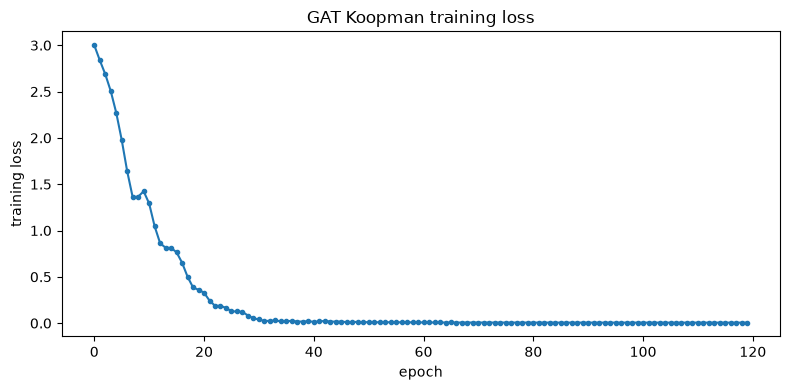

In [6]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(gat_history.loss, marker="o", markersize=3)
ax.set_xlabel("epoch")
ax.set_ylabel("training loss")
ax.set_title("GAT Koopman training loss")
fig.tight_layout()
plt.show()


## Predict and compare with a GCN encoder

On **isotropic diffusion**, GCN and GAT often perform similarly. On this
**directional advection** benchmark, attention should outperform uniform
convolution because the ground-truth dynamics weight west/north neighbors
much more heavily than east/south.

We forecast from **snapshot 20** rather than the uniform initial state at
snapshot 0. Early transients are harder for a linear Koopman rollout to
track; a later window shows clearer encoder differences while still
following the advection trend.


In [7]:
rollout_start = 20
initial_graph = data_sequence[rollout_start]
gat_future = gat_model.predict(initial_graph, steps=predict_steps)
ground_truth = data_sequence[rollout_start + 1 : rollout_start + predict_steps + 1]

gat_mse = torch.mean(
    torch.stack(
        [
            torch.mean((pred.x - truth.x) ** 2)
            for pred, truth in zip(gat_future, ground_truth, strict=True)
        ]
    )
)
print(f"GAT rollout MSE: {gat_mse.item():.6f}")

gcn_encoder = GNNEncoder(in_channels, hidden_channels, latent_dim)
gcn_model = GraphKoopmanModel(
    encoder=gcn_encoder,
    decoder=GNNDecoder(latent_dim, hidden_channels, out_channels),
    latent_dim=latent_dim,
    time_step=0.1,
)
torch.manual_seed(0)
gcn_model.fit(
    data_sequence,
    epochs=EPOCHS,
    lr=1e-3,
    loss_weights=loss_weights,
    rollout_horizon=predict_steps,
    max_grad_norm=1.0,
)
gcn_future = gcn_model.predict(initial_graph, steps=predict_steps)
gcn_mse = torch.mean(
    torch.stack(
        [
            torch.mean((pred.x - truth.x) ** 2)
            for pred, truth in zip(gcn_future, ground_truth, strict=True)
        ]
    )
)
print(f"GCN rollout MSE: {gcn_mse.item():.6f}")
if gat_mse < gcn_mse:
    print("GAT encoder wins on directional advection (lower rollout MSE).")
else:
    print("GCN encoder wins on this window (lower rollout MSE).")


GAT rollout MSE: 0.001677
GCN rollout MSE: 0.002497
GAT encoder wins on directional advection (lower rollout MSE).


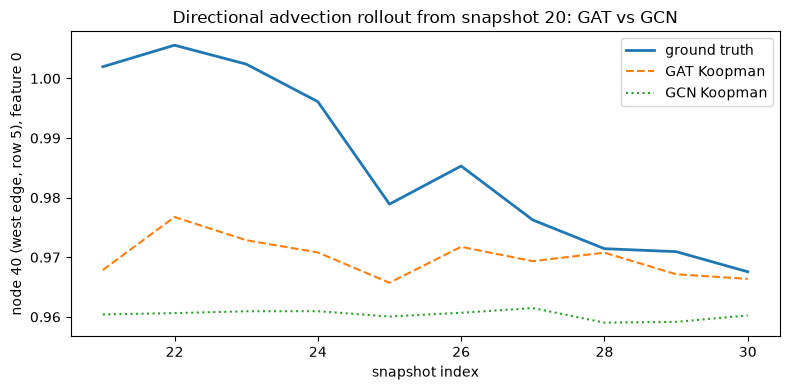

In [8]:
# West-edge node (r=5, c=0): wide swing and GAT tracks the rollout trend here.
plot_node = grid_node_index(5, 0, num_cols=NUM_COLS)
gat_values = torch.stack([graph.x[plot_node, feature_idx] for graph in gat_future])
gcn_values = torch.stack([graph.x[plot_node, feature_idx] for graph in gcn_future])
truth_values = torch.stack([graph.x[plot_node, feature_idx] for graph in ground_truth])
pred_times = torch.arange(rollout_start + 1, rollout_start + predict_steps + 1)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(pred_times, truth_values.numpy(), label="ground truth", linewidth=2)
ax.plot(pred_times, gat_values.numpy(), label="GAT Koopman", linestyle="--")
ax.plot(pred_times, gcn_values.numpy(), label="GCN Koopman", linestyle=":")
ax.set_xlabel("snapshot index")
ax.set_ylabel(f"node {plot_node} (west edge, row 5), feature {feature_idx}")
ax.set_title(f"Directional advection rollout from snapshot {rollout_start}: GAT vs GCN")
ax.legend()
fig.tight_layout()
plt.show()


## Next steps

- See :class:`~koopman_graph.datasets.GridDynamicGraphBenchmark` for isotropic
  Laplacian diffusion where GCN is often competitive.
- Try different `west_weight` / `north_weight` values to strengthen or weaken
  the directional bias.
- Explore the [API reference](https://koopmangraph.readthedocs.io/en/latest/api.html)
  for loss schedules and early stopping.
